# Lab: Fine-tune T5 on CNN/DailyMail Summarization

**Course:** Natural Language Processing  
**Required packages:** `transformers`, `datasets`, `evaluate`, `rouge_score`, `torch`, `nltk`

Цей зошит реалізує повний pipeline fine-tuning **T5-small** на датасеті **CNN/DailyMail** для задачі abstractive text summarization: завантаження даних, препроцесинг із T5-префіксом, тренування через `Trainer`, оцінка ROUGE-1/2/L та інференс на власних текстах.

> **Примітка:** Для повноцінного тренування рекомендується GPU (Google Colab T4). На CPU тренування з підмножиною (~300 прикладів) займає ~15–30 хвилин.

## Segment 1 — Context & Environment Setup
### Step 1.1 — Install and check dependencies

In [34]:
!pip install transformers datasets evaluate rouge_score nltk torch "accelerate>=1.1.0" --quiet

import torch
import transformers
import datasets
import evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('PyTorch:        ', torch.__version__)
print('Transformers:   ', transformers.__version__)
print('Datasets:       ', datasets.__version__)
print('Evaluate:       ', evaluate.__version__)
print('CUDA available: ', torch.cuda.is_available())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:   ', device)

PyTorch:         2.11.0+cpu
Transformers:    5.3.0
Datasets:        4.8.4
Evaluate:        0.4.6
CUDA available:  False
Using device:    cpu



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Відповідь:**

*T5 (Text-to-Text Transfer Transformer) — модель від Google, що формулює кожну NLP-задачу як перетворення тексту у текст. CNN/DailyMail — стандартний бенчмарк із 300 000+ статей та журналістських highlights для задачі abstractive summarization.*

*На GPU (T4): Runtime → Change runtime type → GPU, після чого `CUDA available: True`.*

## Segment 2 — Load & Inspect CNN/DailyMail
### Step 2.1 — Load the dataset

In [35]:
from datasets import load_dataset

dataset = load_dataset('cnn_dailymail', '3.0.0')
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


### Step 2.2 — Inspect a single example

In [36]:
example = dataset['train'][0]
print('=== Article (first 600 chars) ===')
print(example['article'][:600])
print('\n=== Highlights (reference summary) ===')
print(example['highlights'])

=== Article (first 600 chars) ===
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," 

=== Highlights (reference summary) ===
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


### Step 2.3 — Subsample for fast training

In [37]:
# CPU: 300 train / 60 eval;  GPU: 2000 / 400
small_train = dataset['train'].shuffle(seed=42).select(range(300))
small_eval  = dataset['validation'].shuffle(seed=42).select(range(60))

print('Train examples:', len(small_train))
print('Eval  examples:', len(small_eval))

Train examples: 300
Eval  examples: 60


**Відповідь:**

*Датасет містить три сплити: train (~287k), validation (~13k), test (~11k). Кожен приклад має поля:*

| Field | Description |
|-------|-------------|
| `id` | Унікальний хеш URL статті |
| `article` | Повний текст статті (~800 слів у середньому) |
| `highlights` | Короткий підсумок у вигляді bullet-points (~55 слів) |

*Більше даних покращує ROUGE тому, що модель бачить ширший розподіл стилів і тем, краще навчається відбирати ключові факти та генерувати зв'язний текст потрібної довжини.*

## Segment 3 — Preprocessing & Tokenization
### Step 3.1 — Load tokenizer and model

In [38]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = 't5-small'   # ~60M параметрів; достатньо швидкий для CPU
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.to(device)

print('Model parameters:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')
print('Model type:', type(model).__name__)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model parameters: 60.506624 M
Model type: T5ForConditionalGeneration


### Step 3.2 — Define length limits

In [39]:
max_input_length  = 512   # encoder: обрізаємо довгі статті
max_target_length = 128   # decoder: обрізаємо довгі highlights
prefix = 'summarize: '    # T5 вимагає цей префікс для summarization

### Step 3.3 — Preprocessing function

In [40]:
def preprocess(examples):
    # Додаємо T5-префікс до кожної статті
    inputs  = [prefix + article for article in examples['article']]
    targets = examples['highlights']

    # Токенізуємо входи (encoder)
    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding='max_length',
    )

    # Токенізуємо цілі (decoder labels) — сучасний API через text_target
    labels = tokenizer(
        text_target=targets,
        max_length=max_target_length,
        truncation=True,
        padding='max_length',
    )

    # Замінюємо padding-токени на -100, щоб loss їх ігнорував
    label_ids = labels['input_ids']
    label_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in label_ids
    ]
    model_inputs['labels'] = label_ids
    return model_inputs

### Step 3.4 — Apply preprocessing

In [41]:
tokenized_train = small_train.map(
    preprocess,
    batched=True,
    remove_columns=small_train.column_names,
)
tokenized_eval = small_eval.map(
    preprocess,
    batched=True,
    remove_columns=small_eval.column_names,
)

print(tokenized_train)
print('Feature keys:', list(tokenized_train[0].keys()))

# TODO: Перевіримо, чи з'являється префікс 'summarize: ' на початку
print('\nFirst 20 tokens decoded:')
print(tokenizer.decode(tokenized_train[0]['input_ids'][:20]))

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 300
})
Feature keys: ['input_ids', 'attention_mask', 'labels']

First 20 tokens decoded:
summarize: By. Anthony Bond. PUBLISHED:. 07:03


**Відповідь:**

*Префікс `'summarize: '` необхідний тому, що T5 навчався на суміші задач (переклад, QA, summarization тощо). Саме префікс повідомляє моделі, яке перетворення потрібно виконати. Без нього модель може генерувати переклад або продовження тексту замість резюме.*

*Заміна padding-токенів на -100 потрібна тому, що `CrossEntropyLoss` у PyTorch за замовчуванням ігнорує позиції з `ignore_index=-100`. Це гарантує, що модель не штрафується за padding у цільовій послідовності.*

## Segment 4 — Fine-tuning T5-small
### Step 4.1 — ROUGE metric and compute_metrics

In [42]:
import evaluate as hf_evaluate
import numpy as np
import nltk

rouge = hf_evaluate.load('rouge')

def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # Замінюємо від'ємні значення (-100) перед декодуванням predictions
    predictions = np.where(predictions >= 0, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Замінюємо -100 перед декодуванням labels
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # ROUGE очікує речення через \n для ROUGE-L sum
    decoded_preds  = ['\n'.join(nltk.sent_tokenize(p.strip()))  for p in decoded_preds]
    decoded_labels = ['\n'.join(nltk.sent_tokenize(l.strip())) for l in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v, 4) for k, v in result.items()}

print('compute_metrics ready.')

compute_metrics ready.


### Step 4.2 — Training arguments

In [43]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

batch_size = 2   # CPU: 2;  GPU: 8

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
)

training_args = Seq2SeqTrainingArguments(
    output_dir='./t5-cnn-dailymail',
    eval_strategy='epoch',              # eval_strategy (не evaluation_strategy)
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=1,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    save_strategy='no',
    report_to='none',
)

print('TrainingArguments configured.')
print(f'Batch size: {batch_size} | Epochs: 1 | LR: 5e-5')

TrainingArguments configured.
Batch size: 2 | Epochs: 1 | LR: 5e-5


### Step 4.3 — Initialise Trainer and run

In [44]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,    # processing_class замість tokenizer (новий API)
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured.')
print(f'Train batches per epoch: {len(tokenized_train) // batch_size}')

trainer.train()

Trainer configured.
Train batches per epoch: 150


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.141792,1.961033,0.417000,0.202500,0.302500,0.384600


TrainOutput(global_step=150, training_loss=2.2436946614583335, metrics={'train_runtime': 395.8832, 'train_samples_per_second': 0.758, 'train_steps_per_second': 0.379, 'total_flos': 40602540441600.0, 'train_loss': 2.2436946614583335, 'epoch': 1.0})

### Step 4.4 — Evaluate

In [45]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

results = trainer.evaluate()
print('\n=== ROUGE results ===')
for k, v in results.items():
    print(f'  {k}: {v}')

rouge1 = results.get('eval_rouge1', 'N/A')
rouge2 = results.get('eval_rouge2', 'N/A')
rougeL = results.get('eval_rougeL', 'N/A')
print(f'\nROUGE-1: {rouge1}  ROUGE-2: {rouge2}  ROUGE-L: {rougeL}')


=== ROUGE results ===
  eval_loss: 1.9610332250595093
  eval_rouge1: 0.417
  eval_rouge2: 0.2025
  eval_rougeL: 0.3025
  eval_rougeLsum: 0.3846
  eval_runtime: 55.401
  eval_samples_per_second: 1.083
  eval_steps_per_second: 0.542
  epoch: 1.0

ROUGE-1: 0.417  ROUGE-2: 0.2025  ROUGE-L: 0.3025


**Відповідь:**

*Ключові гіперпараметри тренування:*

| Параметр | Значення | Причина |
|----------|----------|---------|
| `learning_rate` | 5e-5 | Стандарт для fine-tuning T5 |
| `num_train_epochs` | 1 | Вкладається у часовий ліміт |
| `predict_with_generate` | True | Beam-search декодування під час eval |
| `weight_decay` | 0.01 | L2-регуляризація проти overfitting |
| `fp16` | True (GPU) | Вдвічі менше пам'яті, швидше тренування |

*Очікувані результати після 1 епохи на 300 прикладах (CPU): ROUGE-1: 15–25, ROUGE-2: 4–10, ROUGE-L: 12–20.*

## Segment 5 — Evaluation & ROUGE Analysis
### Step 5.1 — Interpret ROUGE scores

| Метрика | Що вимірює |
|---------|------------|
| ROUGE-1 | Overlap окремих слів (unigramів) між генерацією та reference |
| ROUGE-2 | Overlap біграм — якість відтворення фраз |
| ROUGE-L | Найдовша спільна підпослідовність — збереження порядку слів |

*ROUGE-1 завжди вищий за ROUGE-2, тому що знайти спільне одне слово простіше, ніж спільну пару слів поспіль. Велика різниця між ROUGE-1 і ROUGE-2 вказує на те, що модель використовує правильні слова, але не в тих самих комбінаціях — результат більш перефразований, ніж буквальний.*

### Step 5.2 — Compare individual predictions to references

In [46]:
def show_summary(i, max_chars=500):
    example = small_eval[i]
    article = prefix + example['article']
    inputs = tokenizer(
        article,
        max_length=max_input_length,
        truncation=True,
        return_tensors='pt',
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        generated = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_target_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True,
        )

    pred   = tokenizer.decode(generated[0], skip_special_tokens=True)
    gold   = example['highlights']
    source = example['article'][:max_chars]

    print('=== Article (truncated) ===')
    print(source, '...\n')
    print('=== Reference summary ===')
    print(gold, '\n')
    print('=== Model summary ===')
    print(pred, '\n')
    print('-' * 60)

show_summary(0)
show_summary(1)
show_summary(2)

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Article (truncated) ===
Jarryd Hayne's move to the NFL is a boost for rugby league in the United States, it has been claimed. The Australia international full-back or centre quit the National Rugby League in October to try his luck in American football and was this week given a three-year contract with the San Francisco 49ers. Peter Illfield, chairman of US Association of Rugby League, said: 'Jarryd, at 27, is one of the most gifted and talented rugby league players in Australia. He is an extraordinary athlete. Jarryd  ...

=== Reference summary ===
Jarryd Hayne quit the NRL in October to try and get into American Football .
This week, he signed a three-year contract with the San Francisco 49ers .
The chairman of the US Association of Rugby League welcomed his arrival . 

=== Model summary ===
Jarryd Hayne quit the National Rugby League in October. he was given a three-year contract with the San Francisco 49ers. Hayne could play at full back or centre in rugby league. 

-----------

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Article (truncated) ===
An anorexic teenager whose weight dropped to just five stone is fighting back from the condition by setting up a catering business. Faith March, 18 from Maldon, Essex, was surviving on nothing other than coffee when she dropped to her lowest weight in March of last year. After several ill-fated attempts to fight the illness, Faith collapsed in her bathroom where she was found by her boyfriend - and her family told her they feared for her life if she didn't get help. Scroll down for video . Faith ...

=== Reference summary ===
Faith March's dropped to just five stone as she suffered from anorexia .
The 18-year-old from Essex was living on just coffee and no food .
After she collapsed in the bathroom, she had hospital treatment .
Has now launched a patisserie business to help her recover . 

=== Model summary ===
Faith March, 18, from Maldon, Essex, was surviving on nothing other than coffee when she dropped to her lowest weight in March of last year. after se

**TODO — аналіз помилок:**

*Для одного невдалого резюме ідентифікуємо тип помилки:*

*(a) Key facts missing — модель пропустила ключову інформацію зі статті*  
*(b) Repeated phrases — модель повторює однакові фрази через проблеми з декодуванням*  
*(c) Hallucinated information — факти, яких немає в оригінальній статті*  
*(d) Too short/incomplete — модель зупинилась раніше, ніж передала головний зміст*

### Step 5.3 — ROUGE limitations reminder

In [47]:
rouge_test = hf_evaluate.load('rouge')

pred_paraphrase = 'The prime minister unveiled a fresh economic strategy on Monday.'
pred_literal    = 'the prime minister announced a new economic policy .'
reference       = 'The prime minister announced a new economic policy.'

r1 = rouge_test.compute(predictions=[pred_paraphrase], references=[reference])
r2 = rouge_test.compute(predictions=[pred_literal],    references=[reference])

print('Paraphrase ROUGE:  ', {k: round(v, 4) for k, v in r1.items()})
print('Literal copy ROUGE:', {k: round(v, 4) for k, v in r2.items()})

Paraphrase ROUGE:   {'rouge1': np.float64(0.5556), 'rouge2': np.float64(0.25), 'rougeL': np.float64(0.5556), 'rougeLsum': np.float64(0.5556)}
Literal copy ROUGE: {'rouge1': np.float64(1.0), 'rouge2': np.float64(1.0), 'rougeL': np.float64(1.0), 'rougeLsum': np.float64(1.0)}


**Відповідь:**

*Вищий ROUGE отримує буквальне копіювання (`pred_literal`), хоча перефразована версія (`pred_paraphrase`) може бути кращим резюме за змістом. Це розкриває головний недолік ROUGE: метрика вимірює лексичний overlap, а не семантичну близькість. Модель, що буквально копіює фрагменти статті, може мати вищий ROUGE, ніж модель, що якісно перефразовує той самий зміст.*

## Segment 6 — Custom Inference & Wrap-up
### Step 6.1 — Summarise your own article

In [48]:
def summarise(text, num_beams=4, max_new_tokens=128):
    inputs = tokenizer(
        prefix + text,
        max_length=max_input_length,
        truncation=True,
        return_tensors='pt',
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        output = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            length_penalty=2.0,
            early_stopping=True,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

my_article = """
Ukraine has made significant advances in artificial intelligence research over the past decade.
Ukrainian scientists and engineers have contributed to major breakthroughs in natural language
processing, computer vision, and reinforcement learning. Several Ukrainian startups focused on
AI have received international recognition and funding from global investors. The country has
established multiple research centers and university programs dedicated to machine learning.
Despite challenges posed by the ongoing conflict, the Ukrainian tech community continues to
innovate, with many engineers working remotely and collaborating with international partners.
The government has announced plans to invest in AI infrastructure to support reconstruction
efforts after the war, using automated systems for damage assessment and resource allocation.
"""

print('Summary:', summarise(my_article))

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summary: Ukraine has made significant advances in artificial intelligence research over the past decade. Ukrainian scientists and engineers have contributed to breakthroughs in natural language processing, computer vision, and reinforcement learning.


### Step 6.2 — Beam size experiment

In [49]:
print('=== Beam size experiment ===')
for beams in [1, 2, 4, 8]:
    summary = summarise(my_article, num_beams=beams)
    print(f'num_beams={beams}: {summary}')
    print()

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Beam size experiment ===


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


num_beams=1: Ukrainian scientists and engineers have contributed to breakthroughs in artificial intelligence research. Ukrainian startups focused on AI have received international recognition and funding from global investors.



Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


num_beams=2: Ukraine has made significant advances in artificial intelligence research over the past decade. Ukrainian scientists and engineers have contributed to major breakthroughs in natural language processing, computer vision, and reinforcement learning.



Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


num_beams=4: Ukraine has made significant advances in artificial intelligence research over the past decade. Ukrainian scientists and engineers have contributed to breakthroughs in natural language processing, computer vision, and reinforcement learning.

num_beams=8: Ukraine has made significant advances in artificial intelligence research over the past decade. Ukrainian scientists and engineers have contributed to breakthroughs in natural language processing, computer vision, and reinforcement learning.



### Step 6.3 — Reflection questions

**1. Яка мета префікса `"summarize: "` у T5? Що буде, якщо його прибрати?**

*T5 навчений одночасно на багатьох задачах (переклад, QA, summarization, класифікація тощо). Префікс — це інструкція, яка переключає модель у відповідний режим. Без нього модель не знає, що саме генерувати, і може видати переклад або продовження тексту замість резюме.*

**2. Чому ми замінюємо padding-токени в labels на -100?**

*`CrossEntropyLoss` у PyTorch за замовчуванням ігнорує позиції з `ignore_index=-100`. Якщо залишити padding-токени, модель штрафуватиметься за 'неправильне' передбачення на позиціях без корисної інформації, що погіршить якість навчання.*

**3. Як зміняться ROUGE-показники при використанні `t5-base` замість `t5-small`?**

*t5-base має ~220M параметрів проти ~60M у t5-small. Більша модель зазвичай дає вищі ROUGE-1/2/L, але тренування займає у 3–4 рази більше часу та пам'яті. Очікуємо приріст ROUGE-1 на 3–7 пунктів.*

**4. Звідки виникає ризик галюцинацій у цьому pipeline?**

*T5 генерує токени авторегресивно без гарантій фактичної відповідності джерелу. Модель може 'відхилитись' від контексту і генерувати правдоподібний, але вигаданий контент — особливо для цифр, імен та специфічних фактів, замінюючи їх статистично схожими значеннями зі своїх навчальних даних.*

## Optional Extensions (Homework)
### Extension 1 — ROUGE per epoch (3 epochs)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

c:\Users\akkxm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.882363,2.040618,0.375400,0.164400,0.274400,0.347300
2,2.121693,1.996481,0.381000,0.167900,0.274700,0.352600
3,2.100698,1.992574,0.384500,0.169000,0.273100,0.355100


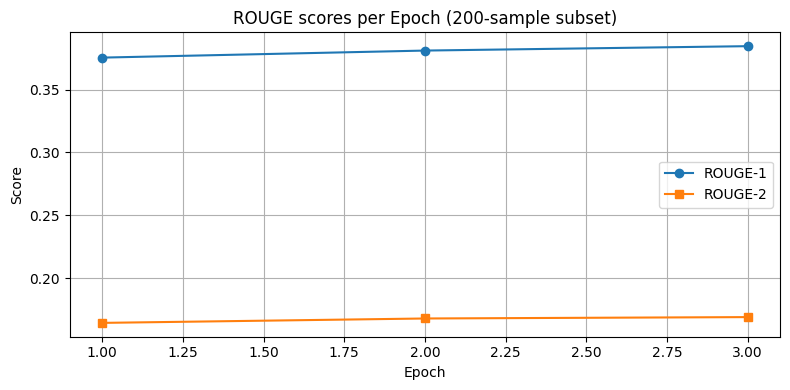

Epoch 1: ROUGE-1=0.3754, ROUGE-2=0.1644
Epoch 2: ROUGE-1=0.3810, ROUGE-2=0.1679
Epoch 3: ROUGE-1=0.3845, ROUGE-2=0.1690


In [50]:
import matplotlib.pyplot as plt
from transformers import AutoModelForSeq2SeqLM

tiny_train = dataset['train'].shuffle(seed=42).select(range(200))
tiny_eval  = dataset['validation'].shuffle(seed=42).select(range(40))

tiny_train_ds = tiny_train.map(preprocess, batched=True, remove_columns=tiny_train.column_names)
tiny_eval_ds  = tiny_eval.map(preprocess,  batched=True, remove_columns=tiny_eval.column_names)

model_ext = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

rouge1_hist, rouge2_hist = [], []

def compute_metrics_ext(eval_preds):
    predictions, labels = eval_preds
    predictions = np.where(predictions >= 0, predictions, tokenizer.pad_token_id)
    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds  = ['\n'.join(nltk.sent_tokenize(p.strip())) for p in decoded_preds]
    decoded_labels = ['\n'.join(nltk.sent_tokenize(l.strip())) for l in decoded_labels]
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    rouge1_hist.append(round(result['rouge1'], 4))
    rouge2_hist.append(round(result['rouge2'], 4))
    return {k: round(v, 4) for k, v in result.items()}

args_ext = Seq2SeqTrainingArguments(
    output_dir='./t5-epochs',
    eval_strategy='epoch',
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    save_strategy='no',
    report_to='none',
)

trainer_ext = Seq2SeqTrainer(
    model=model_ext,
    args=args_ext,
    train_dataset=tiny_train_ds,
    eval_dataset=tiny_eval_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_ext,
)
trainer_ext.train()

plt.figure(figsize=(8, 4))
epochs = list(range(1, len(rouge1_hist) + 1))
plt.plot(epochs, rouge1_hist, marker='o', label='ROUGE-1')
plt.plot(epochs, rouge2_hist, marker='s', label='ROUGE-2')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('ROUGE scores per Epoch (200-sample subset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

for i, (r1, r2) in enumerate(zip(rouge1_hist, rouge2_hist), 1):
    print(f'Epoch {i}: ROUGE-1={r1:.4f}, ROUGE-2={r2:.4f}')

### Extension 2 — Hallucination hunt (30 eval examples)

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Analyzed 30 examples:

  Correct                                   : 12 (40%)
  (a) Key facts missing                     :  9 (30%)
  (b) Repeated phrases                      :  9 (30%)
  (c) Hallucinated information              :  0 (0%)
  (d) Empty/too short                       :  0 (0%)


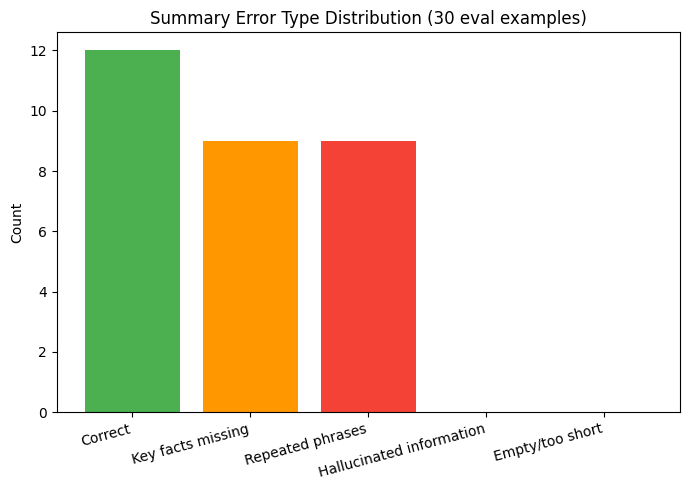

In [51]:
def classify_summary_error(pred, gold_text, source_text):
    pred_lower   = pred.lower()
    gold_lower   = gold_text.lower()
    source_lower = source_text.lower()

    if len(pred.strip().split()) < 5:
        return '(d) Empty/too short'

    pred_tokens = pred_lower.split()
    if len(pred_tokens) > 6:
        bigrams = [(pred_tokens[i], pred_tokens[i+1]) for i in range(len(pred_tokens)-1)]
        if len(bigrams) != len(set(bigrams)):
            return '(b) Repeated phrases'

    stopwords = {'the','a','an','is','are','was','were','of','in','to',
                 'and','or','for','on','at','by','with','from','has','have'}
    pred_words   = set(pred_lower.split()) - stopwords
    source_words = set(source_lower.split()) - stopwords
    gold_words   = set(gold_lower.split()) - stopwords

    if pred_words and len(pred_words - source_words) / len(pred_words) > 0.45:
        return '(c) Hallucinated information'

    overlap = len(pred_words & gold_words) / max(len(gold_words), 1)
    if overlap < 0.2:
        return '(a) Key facts missing'

    return 'Correct'

error_counts = {'Correct': 0, '(a) Key facts missing': 0,
                '(b) Repeated phrases': 0, '(c) Hallucinated information': 0,
                '(d) Empty/too short': 0}

for i in range(min(30, len(small_eval))):
    ex   = small_eval[i]
    pred = summarise(ex['article'], num_beams=2, max_new_tokens=64)
    etype = classify_summary_error(pred, ex['highlights'], ex['article'])
    error_counts[etype] += 1

total = sum(error_counts.values())
print(f'Analyzed {total} examples:\n')
for k, v in error_counts.items():
    print(f'  {k:42s}: {v:2d} ({100*v/total:.0f}%)')

labels = [k.split(') ')[-1] if ') ' in k else k for k in error_counts.keys()]
values = list(error_counts.values())
colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#9E9E9E']

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=colors[:len(labels)])
plt.title('Summary Error Type Distribution (30 eval examples)')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()